## Preprocessing Choices
- Images resized to 224×224×3, normalized to [0.0, 1.0] (float32)
- Bounding boxes scaled to 224×224 pixel space, stored as (x, y, width, height) where (x, y) is the top-left corner
- Saved to `preprocessed_data/images.npy` (N, 224, 224, 3) and `preprocessed_data/bboxes.npy` (N, 4)
- Images without XML annotations are skipped (~3,704 of 7,390 total)

In [2]:
import os
import numpy as np
import xml.etree.ElementTree as ET
from PIL import Image
from tqdm import tqdm

In [ ]:
#Download Images and Annotations: Note this will take ~ 3 mins depending on internet speed - Charlie

import urllib.request
import tarfile
import os

os.makedirs("../raw_data", exist_ok=True)

urls = {
    "images": "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz",
    "annotations": "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"
}

for name, url in urls.items():
    dest = f"../raw_data/{name}.tar.gz"
    print(f"Downloading {name}...")
    urllib.request.urlretrieve(url, dest)
    print(f"Extracting {name}...")
    with tarfile.open(dest) as tar:
        tar.extractall("../raw_data")
    os.remove(dest)
    print(f"Done with {name}")

Extracting images...
Done with images
Extracting annotations...
Done with annotations


In [3]:
IMAGE_DIR = os.path.join("..", "raw_data", "images")
ANNOTATION_DIR = os.path.join("..", "raw_data", "annotations", "xmls")
OUTPUT_DIR = os.path.join("..", "preprocessed_data")

TARGET_SIZE = (224, 224)

In [4]:
img_filenames = [f for f in os.listdir(IMAGE_DIR) if f.endswith(".jpg")]
print(f"Found {len(img_filenames)} images")

Found 7390 images


In [5]:
X = []
Y = []
skipped = []

for fname in tqdm(img_filenames):
    annotation_path = os.path.join(ANNOTATION_DIR, os.path.splitext(fname)[0] + ".xml")

    if not os.path.exists(annotation_path):
        skipped.append(fname)
        continue

    img = Image.open(os.path.join(IMAGE_DIR, fname)).convert("RGB")
    orig_w, orig_h = img.size
    img = img.resize(TARGET_SIZE)

    root = ET.parse(annotation_path).getroot()
    bndbox = root.find("object").find("bndbox")
    xmin = int(bndbox.find("xmin").text)
    ymin = int(bndbox.find("ymin").text)
    xmax = int(bndbox.find("xmax").text)
    ymax = int(bndbox.find("ymax").text)

    # Scale bbox to match resized image
    x_scale = TARGET_SIZE[0] / orig_w
    y_scale = TARGET_SIZE[1] / orig_h
    x = xmin * x_scale
    y = ymin * y_scale
    w = (xmax - xmin) * x_scale
    h = (ymax - ymin) * y_scale

    X.append(np.array(img, dtype=np.float32) / 255.0)
    Y.append([x, y, w, h])  # (x, y, width, height) in 224x224 pixel space

X = np.array(X)  # (N, 224, 224, 3)
Y = np.array(Y)  # (N, 4)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Skipped {len(skipped)} images (no annotation)")

100%|██████████| 7390/7390 [00:08<00:00, 916.51it/s] 


X shape: (3686, 224, 224, 3)
Y shape: (3686, 4)
Skipped 3704 images (no annotation)


In [6]:
#Download files to disc
os.makedirs(OUTPUT_DIR, exist_ok=True)
np.save(os.path.join(OUTPUT_DIR, "images.npy"), X)
np.save(os.path.join(OUTPUT_DIR, "bboxes.npy"), Y)
print("Saved images.npy and bboxes.npy")

Saved images.npy and bboxes.npy


In [6]:
import numpy as np
annotated_fnames_ordered = [f for f in img_filenames if os.path.exists(os.path.join(ANNOTATION_DIR, os.path.splitext(f)[0] + ".xml"))]
breeds = np.array(["_".join(f.split("_")[:-1]) for f in annotated_fnames_ordered])
np.save(os.path.join(OUTPUT_DIR, "breeds.npy"), breeds)
print(f"Saved breeds.npy: {len(breeds)} samples, {len(set(breeds))} unique breeds")

Saved breeds.npy: 3686 samples, 37 unique breeds


## Train / Validation / Test Split (70 / 10 / 20)
Stratified by breed so each split has a consistent class distribution.

In [7]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(X))

train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=breeds[indices], random_state=42)
val_idx, test_idx  = train_test_split(temp_idx, test_size=2/3,  stratify=breeds[temp_idx], random_state=42)

np.save(os.path.join(OUTPUT_DIR, "train_indices.npy"), train_idx)
np.save(os.path.join(OUTPUT_DIR, "val_indices.npy"),   val_idx)
np.save(os.path.join(OUTPUT_DIR, "test_indices.npy"),  test_idx)

print(f"Total:      {len(indices)}")
print(f"Train:      {len(train_idx)} ({len(train_idx)/len(indices):.1%})")
print(f"Validation: {len(val_idx)}  ({len(val_idx)/len(indices):.1%})")
print(f"Test:       {len(test_idx)} ({len(test_idx)/len(indices):.1%})")

Total:      3686
Train:      2580 (70.0%)
Validation: 368  (10.0%)
Test:       738 (20.0%)


In [8]:
# Verify breed balance across splits
unique_breeds = sorted(set(breeds))
print(f"{'Breed':<35} {'Train':>6} {'Val':>5} {'Test':>5}")
print("-" * 55)
for b in unique_breeds:
    tr = (breeds[train_idx] == b).sum()
    v  = (breeds[val_idx]   == b).sum()
    te = (breeds[test_idx]  == b).sum()
    print(f"{b:<35} {tr:>6} {v:>5} {te:>5}")

Breed                                Train   Val  Test
-------------------------------------------------------
Abyssinian                              69    10    20
Bengal                                  69     9    20
Birman                                  70    10    20
Bombay                                  70    10    20
British_Shorthair                       70    10    20
Egyptian_Mau                            65     9    18
Maine_Coon                              70    10    20
Persian                                 70    10    20
Ragdoll                                 69    10    20
Russian_Blue                            70    10    20
Siamese                                 70    10    20
Sphynx                                  70    10    20
american_bulldog                        70    10    20
american_pit_bull_terrier               70    10    20
basset_hound                            70    10    20
beagle                                  70    10    20
boxer    

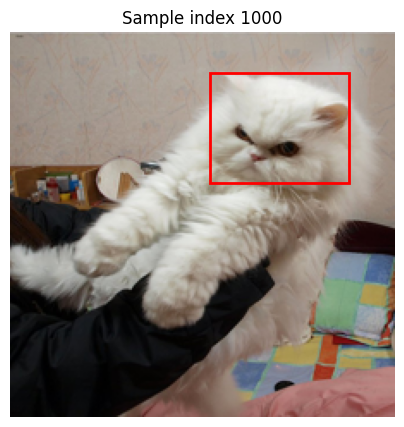

In [9]:
#Display an image, change the number in sample to change the image (1000 is a very grumpy cat)
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_sample(index):
    img = X[index] 
    x, y, w, h = Y[index]

    fig, ax = plt.subplots(1, figsize=(5, 5))
    ax.imshow(img)
    ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none'))
    ax.set_title(f"Sample index {index}")
    ax.axis("off")
    plt.show()

show_sample(1000)

## Exploratory Data Analysis

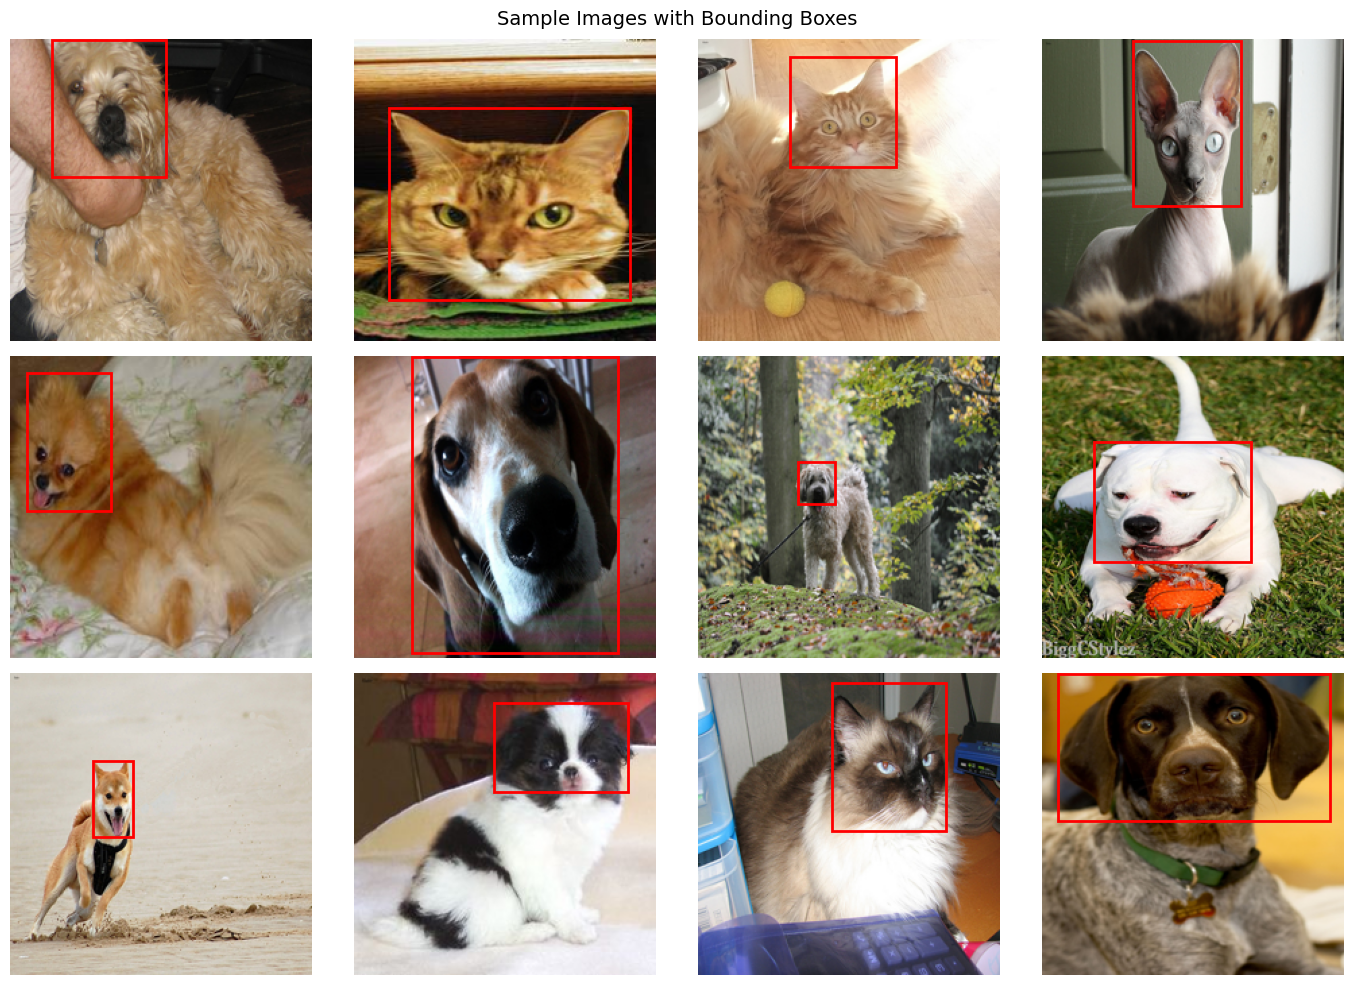

In [10]:
# Grid of sample images with bounding boxes
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
indices = np.random.choice(len(X), 12, replace=False)

for ax, idx in zip(axes.flatten(), indices):
    x, y, w, h = Y[idx]
    ax.imshow(X[idx])
    ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none'))
    ax.axis("off")

plt.suptitle("Sample Images with Bounding Boxes", fontsize=14)
plt.tight_layout()
plt.show()

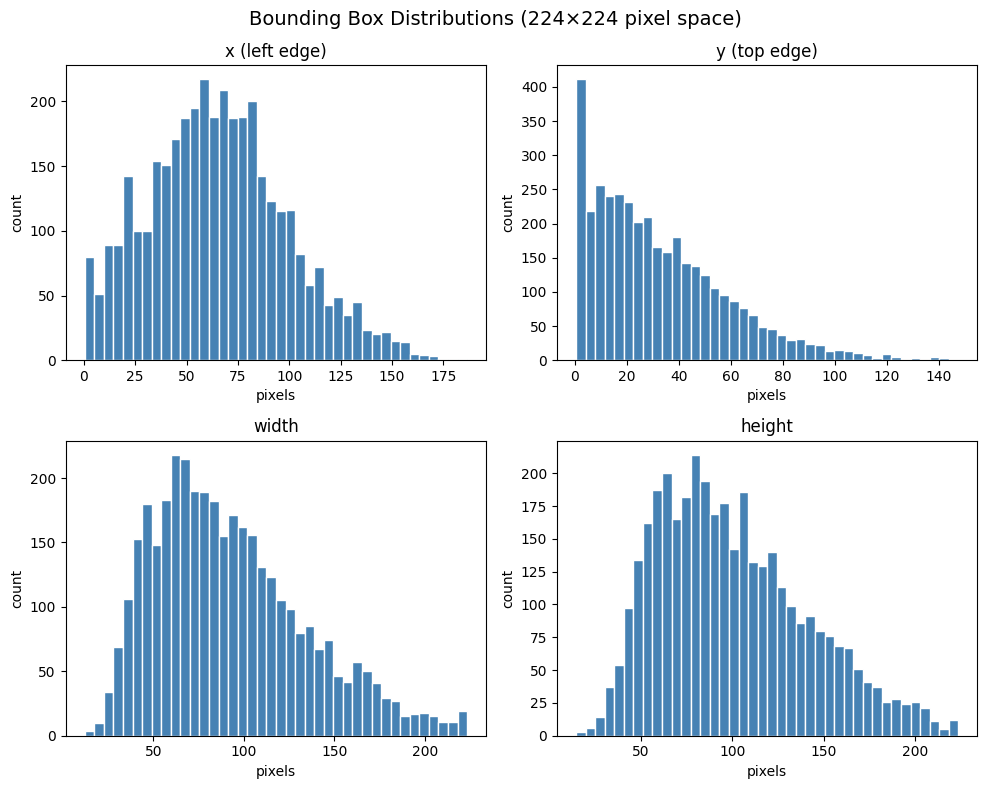

In [33]:
# Bounding box coordinate distributions
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
labels = ["x (left edge)", "y (top edge)", "width", "height"]

for ax, col, label in zip(axes.flatten(), range(4), labels):
    ax.hist(Y[:, col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel("pixels")
    ax.set_ylabel("count")

plt.suptitle("Bounding Box Distributions (224×224 pixel space)", fontsize=14)
plt.tight_layout()
plt.show()

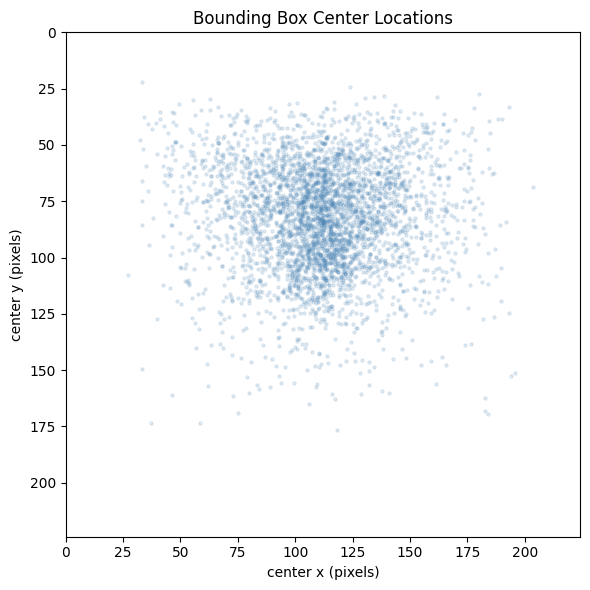

In [34]:
# Scatter plot of bbox centers
cx = Y[:, 0] + Y[:, 2] / 2
cy = Y[:, 1] + Y[:, 3] / 2

plt.figure(figsize=(6, 6))
plt.scatter(cx, cy, alpha=0.15, s=5, color='steelblue')
plt.xlim(0, 224)
plt.ylim(224, 0)  # match image coordinates (y increases downward)
plt.xlabel("center x (pixels)")
plt.ylabel("center y (pixels)")
plt.title("Bounding Box Center Locations")
plt.tight_layout()
plt.show()

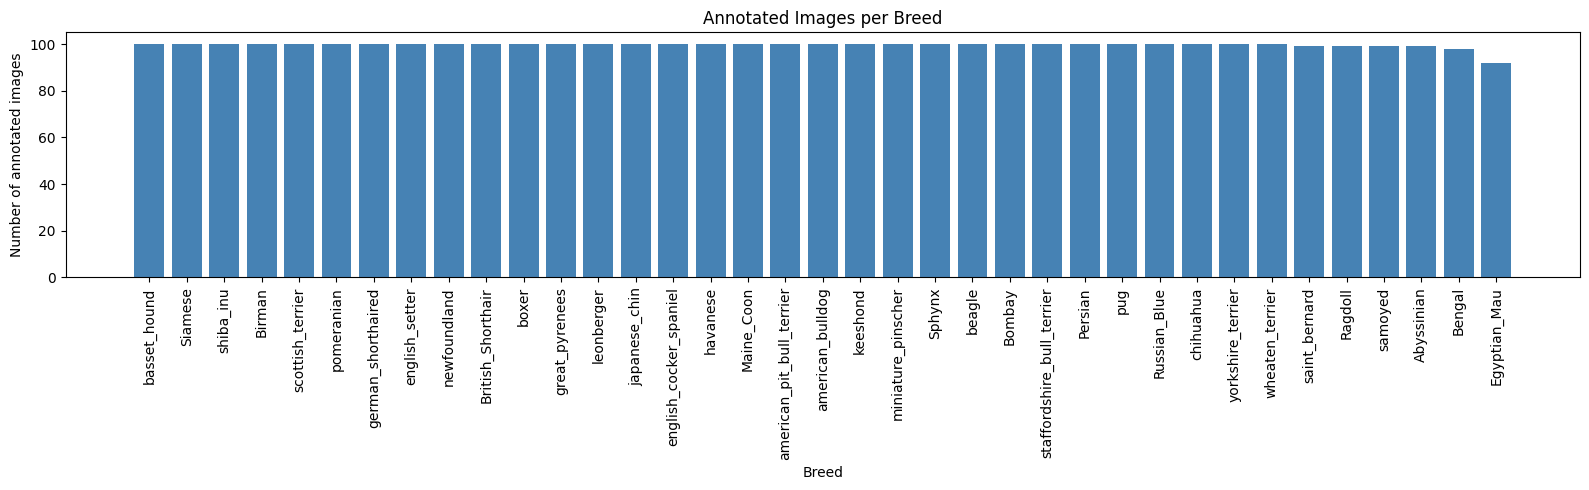

In [35]:
# Breed distribution
from collections import Counter

breeds = ["_".join(f.split("_")[:-1]) for f in img_filenames if os.path.exists(os.path.join(ANNOTATION_DIR, os.path.splitext(f)[0] + ".xml"))]
breed_counts = Counter(breeds)
sorted_breeds = sorted(breed_counts.items(), key=lambda x: x[1], reverse=True)
names, counts = zip(*sorted_breeds)

plt.figure(figsize=(16, 5))
plt.bar(names, counts, color='steelblue')
plt.xticks(rotation=90)
plt.xlabel("Breed")
plt.ylabel("Number of annotated images")
plt.title("Annotated Images per Breed")
plt.tight_layout()
plt.show()

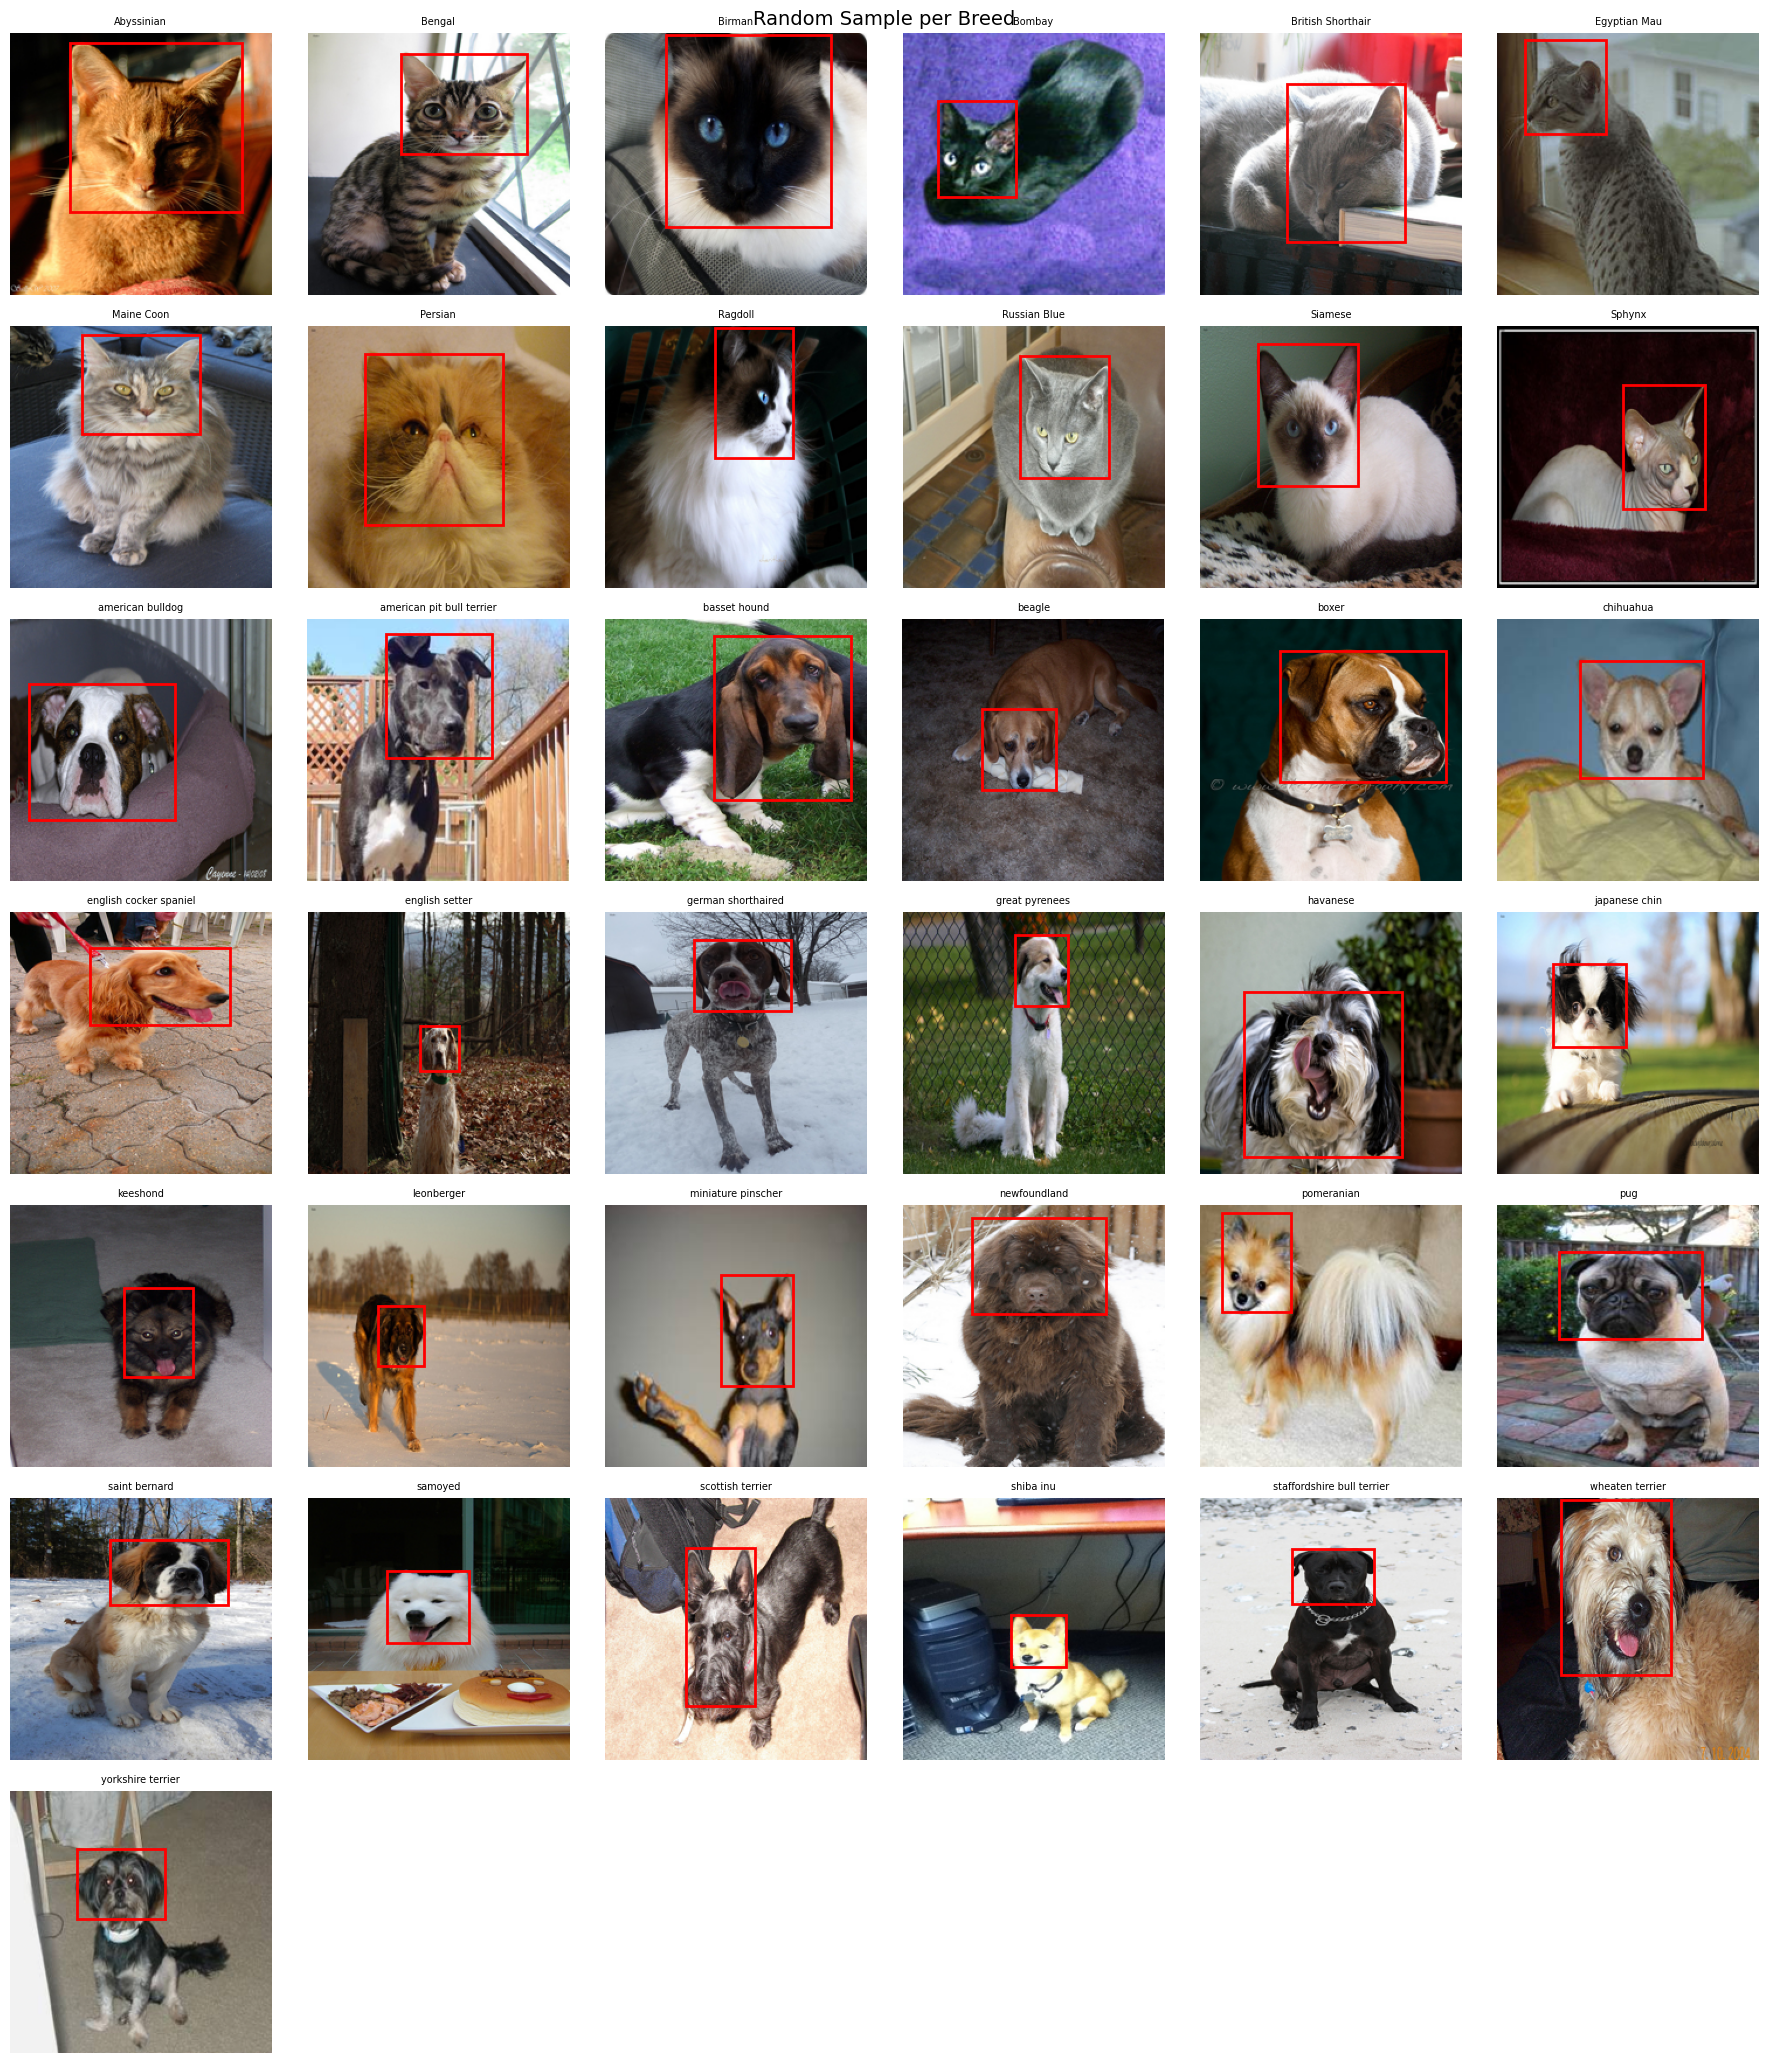

In [37]:
# One random sample per breed
import random

annotated_fnames = [f for f in img_filenames if os.path.exists(os.path.join(ANNOTATION_DIR, os.path.splitext(f)[0] + ".xml"))]
fname_to_idx = {f: i for i, f in enumerate(annotated_fnames)}

by_breed = {}
for f in annotated_fnames:
    breed = "_".join(f.split("_")[:-1])
    by_breed.setdefault(breed, []).append(f)

breed_names = sorted(by_breed.keys())
n = len(breed_names)
cols = 6
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
for ax, breed in zip(axes.flatten(), breed_names):
    fname = random.choice(by_breed[breed])
    idx = fname_to_idx[fname]
    x, y, w, h = Y[idx]
    img = Image.open(os.path.join(IMAGE_DIR, fname)).convert("RGB").resize(TARGET_SIZE)
    ax.imshow(np.array(img))
    ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none'))
    ax.set_title(breed.replace("_", " "), fontsize=7)
    ax.axis("off")

for ax in axes.flatten()[n:]:
    ax.axis("off")

plt.suptitle("Random Sample per Breed", fontsize=14)
plt.tight_layout()
plt.show()